## 1- Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('bank.csv')

# 2. Display basic info
print("First 5 rows:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"Column names: {df.columns.tolist()}")

# 3. Identify data types and non-null counts
print("\nDataset Info:")
df.info()

First 5 rows:
   age         job  marital  education  balance housing loan  contact  day  \
0   59      admin.  married  secondary     2343     yes   no  unknown    5   
1   56      admin.  married  secondary       45      no   no  unknown    5   
2   41  technician  married  secondary     1270     yes   no  unknown    5   
3   55    services  married  secondary     2476     yes   no  unknown    5   
4   54      admin.  married   tertiary      184      no   no  unknown    5   

  month  duration  campaign  pdays  previous deposit  
0   may      1042         1     -1         0     yes  
1   may      1467         1     -1         0     yes  
2   may      1389         1     -1         0     yes  
3   may       579         1     -1         0     yes  
4   may       673         2     -1         0     yes  

Dataset shape: (11162, 15)
Column names: ['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'dep

## 2-Data Handling

In [2]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")



Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'deposit']


## 3- Missing Values Analysis

In [3]:
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Column name': null_counts.index,
    'Number of nulls': null_counts.values,
    'Percentage of nulls': null_percentages.values
})
print(missing_table)

   Column name  Number of nulls  Percentage of nulls
0          age                0                  0.0
1          job                0                  0.0
2      marital                0                  0.0
3    education                0                  0.0
4      balance                0                  0.0
5      housing                0                  0.0
6         loan                0                  0.0
7      contact                0                  0.0
8          day                0                  0.0
9        month                0                  0.0
10    duration                0                  0.0
11    campaign                0                  0.0
12       pdays                0                  0.0
13    previous                0                  0.0
14     deposit                0                  0.0


## 4-Handling Missing Values 

In [4]:
# Method 1: Drop Columns
threshold = 0.4
df_method1 = df.loc[:, df.isnull().mean() <= threshold]

print(f"Columns remaining after dropping those with >40% missing: {df_method1.shape[1]}")

Columns remaining after dropping those with >40% missing: 15


In [5]:
# Method 2: Drop Rows
df_method2 = df.dropna()

print(f"Original number of rows: {df.shape[0]}")
print(f"Rows remaining after dropping nulls: {df_method2.shape[0]}")

Original number of rows: 11162
Rows remaining after dropping nulls: 11162


In [6]:
# Method 3: Imputation
df_imputed = df.copy()

numerical_cols = df_imputed.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_imputed.select_dtypes(include=['object']).columns

for col in numerical_cols:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median()) 

for col in categorical_cols:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode()[0])

print("Missing values after imputation:")
print(df_imputed.isnull().sum())

Missing values after imputation:
age          0
job          0
marital      0
education    0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
deposit      0
dtype: int64


## 5-Basic Data Visualization

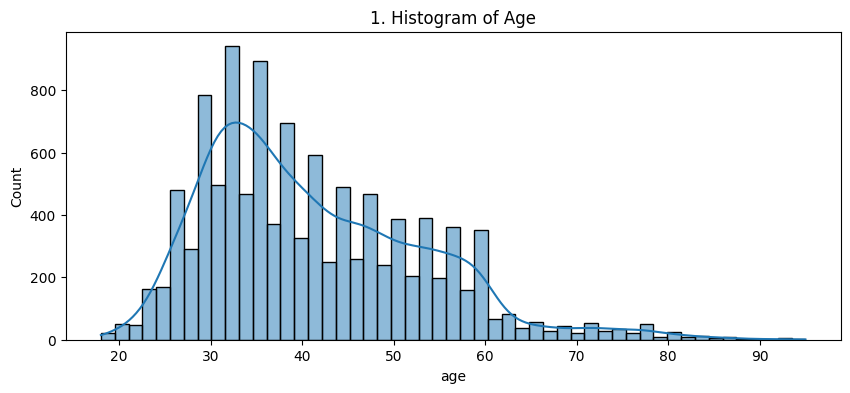

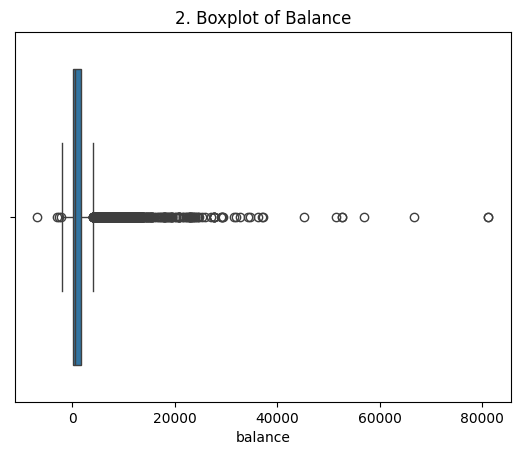

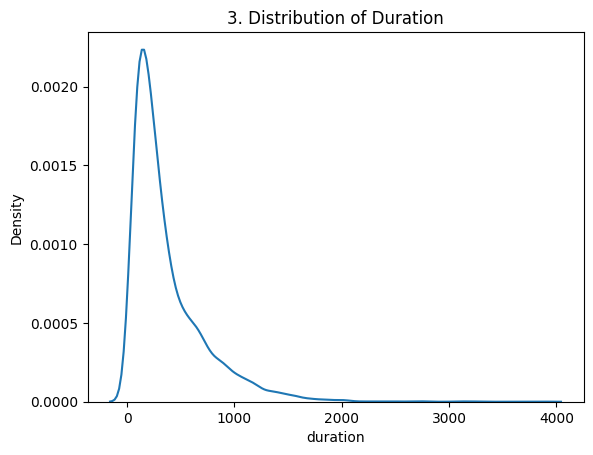

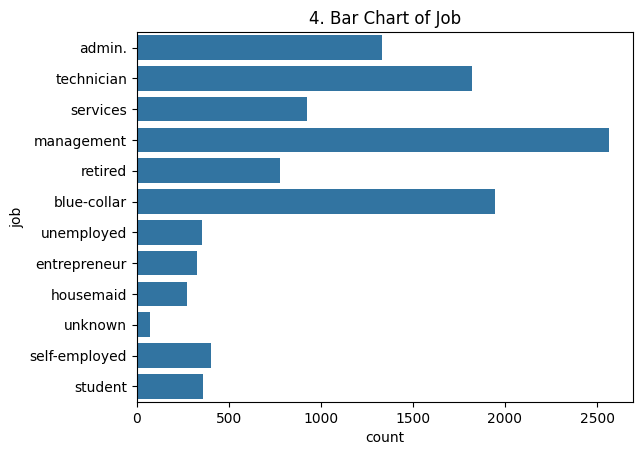

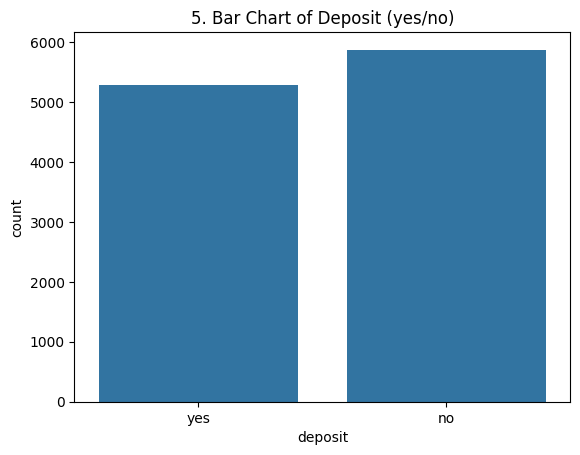

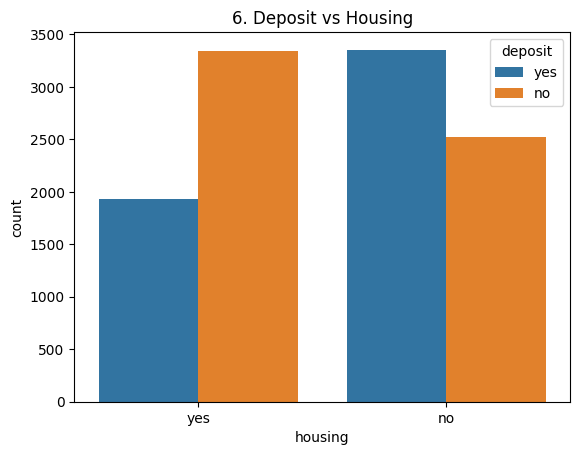

In [7]:
# Numerical Visualizations
plt.figure(figsize=(10, 4))
sns.histplot(df['age'], kde=True).set_title('1. Histogram of Age') # Dist. of ages
plt.show()

sns.boxplot(x=df['balance']).set_title('2. Boxplot of Balance') # Shows outliers in wealth
plt.show()

sns.kdeplot(df['duration']).set_title('3. Distribution of Duration') # Length of last contact
plt.show()

# Categorical Visualizations
sns.countplot(y=df['job']).set_title('4. Bar Chart of Job') # Most common occupations
plt.show()

sns.countplot(x=df['deposit']).set_title('5. Bar Chart of Deposit (yes/no)') # Class balance
plt.show()

# Relationship Plot
sns.countplot(x='housing', hue='deposit', data=df).set_title('6. Deposit vs Housing')
plt.show()

## 6-Part 6: Final Questions (Short Answers)

In [ ]:
# Q1: Which preprocessing method was most effective for this dataset?
# Answer: Imputation is usually most effective 
# for this dataset because it retains all customer records while filling gaps with statistically likely values.

In [ ]:
# Q2: Which preprocessing method was most effective for this dataset?
# Based on common bank marketing analysis, 
# duration (the length of the call) and poutcome (previous success) are typically the strongest predictors

In [ ]:
# Q3: What problems appear if preprocessing is skipped?
# Machine learning models will fail to run on null values, 
# and outliers in columns like balance can heavily skew statistical results